# Tutorial #1: Object Construction

# Annotating latent factors

In this tutorial, we will construct an Ontology object to annotate lineage-restricted, MOFA-derived latent factors from our 3.3 million cell-atlas of GBM single cells/nuclei. We will also visualize and export factor annotations.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

# Format Input Data

Read factor-gene loadings as a DataFrame. Factors should have the name (column) format "FactorN|Cell_Type" (e.g. "Factor0|Tumor"), with rows = genes.

In [2]:
all_factors = pd.read_csv('scFO models/GBM_input/MOFA_no patient regression/all_mofa_weights_no_pt.csv', index_col = 0).fillna(0)
all_factors

,Factor0|Tumor,Factor1|Tumor,Factor2|Tumor,Factor3|Tumor,Factor4|Tumor,Factor5|Tumor,Factor6|Tumor,Factor7|Tumor,Factor8|Tumor,Factor9|Tumor,...,Factor15|Non_Mac_Myelocyte,Factor16|Non_Mac_Myelocyte,Factor17|Non_Mac_Myelocyte,Factor18|Non_Mac_Myelocyte,Factor19|Non_Mac_Myelocyte,Factor20|Non_Mac_Myelocyte,Factor21|Non_Mac_Myelocyte,Factor22|Non_Mac_Myelocyte,Factor23|Non_Mac_Myelocyte,Factor24|Non_Mac_Myelocyte
A2M,0.065872,0.018823,0.009518,0.001424,-0.033175,0.001514,-0.015762,-0.043016,0.016885,-0.009052,...,-9.911358e-06,5.945239e-03,-2.502242e-02,-7.482131e-05,-6.309939e-05,-2.507230e-04,6.727285e-05,3.702271e-03,-2.761166e-03,7.229742e-03
AATK,-0.010462,0.004248,-0.001174,0.001231,-0.009317,-0.001029,-0.017071,0.000024,-0.000262,-0.001706,...,2.775830e-07,-2.399302e-08,-2.730141e-08,4.166084e-09,3.676773e-08,1.202644e-07,-1.184952e-03,-3.113173e-07,3.112070e-07,6.603217e-09
ABCA1,0.084983,0.049310,0.011073,0.001772,-0.098191,-0.003720,0.055033,0.037152,0.027211,0.067417,...,-2.406400e-02,-2.520538e-02,-6.463239e-04,-2.236486e-03,2.557011e-02,1.207453e-02,-2.559648e-06,-2.421025e-02,-8.699688e-03,9.386931e-05
ABCA13,0.012354,-0.002002,0.003916,-0.000464,-0.021593,-0.004375,0.011087,-0.007260,-0.001729,-0.006552,...,-6.829368e-11,-1.914313e-11,-1.025851e-10,-6.566419e-12,-3.688559e-10,2.900353e-11,-1.653126e-11,5.555273e-11,-9.004756e-11,3.646023e-12
ABCA6,0.002728,0.002772,-0.000338,0.000681,-0.001566,-0.000609,0.006748,-0.001359,-0.001304,-0.007204,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF84,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-3.547690e-03,-7.020537e-05,4.353444e-05,-7.471340e-06,3.543787e-03,-1.376266e-05,1.368706e-03,1.031727e-04,1.416973e-04,2.161020e-05
ZNF85,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-2.850178e-07,-1.454784e-03,-1.307464e-06,2.479102e-07,6.460862e-06,6.809009e-08,3.008809e-06,1.819761e-03,1.941407e-04,-2.636626e-03
ZRSR2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.151887e-04,-5.935976e-03,8.014254e-06,5.546243e-03,4.514130e-05,-1.391835e-04,2.589203e-03,-3.214325e-04,1.716484e-05,1.315272e-04
ZSCAN5A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-5.682047e-05,-3.954720e-05,1.192401e-05,-3.389600e-06,-1.475607e-05,1.832603e-07,2.448699e-06,-6.469194e-06,-1.930402e-04,-1.245877e-04


Read continuous/scored modalities as DataFrames. For cell-type specific loadings, feature names (columns) should have format "Feature|Cell_Type" (e.g. "CEBPB(+)|Tumor"), with rows = genes. Weighted modalities are enriched in factors by a permutation-based dot product protocol. 

In this tutorial, we annotate factors with the following weighted modalities, each inferred using our recent 3.3 million-cell GBM atlas:
- Cell type-**specific** transcription factor regulon inferred by PyScenic
- Pair-wise cell type ligand-receptor communication scores, summarized at the whole cell type-level, inferred by Liana
- Cell type-**agnostic** enrichment for downstream ligand effectors using the NicheNet network of prior knowledge
- Cell type-**specific** recurrence/survival scores, derived in our recent study.
- Cell type-**specific** differential expression responses observed in ex vivo slice cultures

In [3]:
all_regulons = pd.read_csv('scFO models/GBM_input/all_regulons.csv', index_col = 0).fillna(0)
all_regulons

,ARID3A(+)|Pericyte,ATF1(+)|Pericyte,ATF4(+)|Pericyte,ATF6(+)|Pericyte,BACH1(+)|Pericyte,BATF3(+)|Pericyte,BCL11A(+)|Pericyte,BCL6(+)|Pericyte,BCLAF1(+)|Pericyte,BDP1(+)|Pericyte,...,ZNF121(+)|Neuron,ZNF274(+)|Neuron,ZNF281(+)|Neuron,ZNF362(+)|Neuron,ZNF382(+)|Neuron,ZNF44(+)|Neuron,ZNF549(+)|Neuron,ZNF568(+)|Neuron,ZNF846(+)|Neuron,ZNF91(+)|Neuron
Gene,,,,,,,,,,,,,,,,,,,,,
FAM227A,0.061385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.945901,0.000000
UBE2O,0.155390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
HLX,0.538265,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
USP42,0.230929,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.746698,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
MARK4,0.062015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.232569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TM7SF2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
ZC3HC1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
ZCCHC10,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [4]:
all_nichenet = pd.read_csv('scFO models/Priors/nichenet_downstream.csv', index_col = 0).fillna(0)
all_nichenet

,ACVR2A~ligand,CISH~ligand,BPHL~ligand,UBA52~ligand,ZDBF2~ligand,PBX3~ligand,PREX2~ligand,SCD~ligand,VPS18~ligand,CHST3~ligand,...,LRRC39~ligand,DPY19L2~ligand,SLC35E2B~ligand,PCDHB4~ligand,ZNF155~ligand,IFRD1~ligand,C15orf61~ligand,B4GALT4~ligand,TRIM11~ligand,SYNJ1~ligand
A2M,0.003810,0.006473,0.003287,0.003500,0.003257,0.003889,0.003053,0.007112,0.003861,0.003089,...,0.001612,0.001874,0.001651,0.002608,0.002374,0.006017,0.001271,0.003476,0.002531,0.004268
AANAT,0.002299,0.003208,0.002090,0.002497,0.001864,0.002378,0.001594,0.004697,0.002305,0.001751,...,0.000921,0.001187,0.001149,0.001275,0.001168,0.003307,0.001003,0.002138,0.001610,0.002562
ABCA1,0.003446,0.005627,0.003082,0.003910,0.002759,0.004006,0.002203,0.006790,0.043257,0.002928,...,0.001271,0.001882,0.001632,0.002411,0.001761,0.006108,0.001386,0.002956,0.002413,0.003632
ACE,0.005466,0.006884,0.005980,0.006388,0.006086,0.006906,0.003563,0.011660,0.005396,0.003855,...,0.002075,0.001841,0.001847,0.004466,0.002855,0.009661,0.001459,0.004826,0.003607,0.006370
ACE2,0.003235,0.004114,0.003818,0.002531,0.001893,0.002733,0.002656,0.004735,0.003255,0.001812,...,0.000862,0.001110,0.001005,0.001543,0.001215,0.003819,0.000922,0.002170,0.001657,0.002574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZDHHC5,0.003057,0.004549,0.002757,0.003143,0.003338,0.004177,0.002219,0.006763,0.003890,0.002845,...,0.001135,0.001478,0.001232,0.002860,0.001848,0.004615,0.001022,0.002750,0.002760,0.003149
ZG16B,0.002756,0.005034,0.003197,0.003172,0.002439,0.003819,0.002115,0.005852,0.002988,0.002056,...,0.001081,0.001393,0.001199,0.001910,0.001510,0.005733,0.001195,0.002662,0.002306,0.003325
ZNRF3,0.003540,0.006979,0.003592,0.002711,0.002891,0.002721,0.002168,0.006013,0.003615,0.002727,...,0.001027,0.001991,0.001237,0.001614,0.001206,0.005507,0.001134,0.003052,0.002995,0.003499
ZP3,0.003944,0.004613,0.002740,0.005144,0.002735,0.003771,0.002372,0.006747,0.003061,0.002243,...,0.001563,0.001550,0.001852,0.002277,0.001788,0.006334,0.001083,0.004030,0.001973,0.002922


In [5]:
all_survival_scores = pd.read_csv('scFO models/Priors/all_survival_scores.csv', index_col = 0).fillna(0)
all_survival_scores

,MLM_Score::mean|Mo_TAM,rec_PRS__factor_1::mean|Mo_TAM,delta_TTR__factor_0::mean|Mo_TAM,pri_TTR__factor_0::mean|Mo_TAM,pri_TTR__factor_2::mean|Mo_TAM,MLM_Score::mean|Mg_TAM,rec_PRS__factor_1::mean|Mg_TAM,delta_TTR__factor_0::mean|Mg_TAM,pri_TTR__factor_0::mean|Mg_TAM,pri_TTR__factor_2::mean|Mg_TAM,...,MLM_Score::std|Endothelial,rec_PRS__factor_1::std|Endothelial,delta_TTR__factor_0::std|Endothelial,pri_TTR__factor_0::std|Endothelial,pri_TTR__factor_2::std|Endothelial,MLM_Score::std|Pericyte,rec_PRS__factor_1::std|Pericyte,delta_TTR__factor_0::std|Pericyte,pri_TTR__factor_0::std|Pericyte,pri_TTR__factor_2::std|Pericyte
A2M,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.068800,-0.232607,-0.021354,-0.121079,-0.044479,0.033356,-0.196944,-0.097601,-0.081034,0.032703
AATK,0.013410,-0.000177,-0.000011,0.001620,0.002426,0.002913,-0.000919,-0.001143,-0.000883,0.003147,...,-0.005128,0.003863,0.006332,0.009177,-0.005453,0.000000,0.000000,0.000000,0.000000,0.000000
ABCA1,0.163463,0.059425,0.023044,0.035016,-0.138084,0.046336,0.009349,0.012803,-0.002113,-0.049773,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.006289,-0.022806,-0.025222,-0.032555,0.005711
ABCA13,-0.000028,0.000005,-0.000007,0.000006,0.000087,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000011,-0.000030,-0.000044,0.000039,-0.000002
ABCA6,0.000708,-0.000516,-0.000295,0.000050,0.000309,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.009667,0.014268,0.009074,0.002834,-0.006967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF84,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZNF85,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZRSR2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ZSCAN5A,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
all_treatment = pd.read_csv('scFO models/Priors/all_treatment.csv', index_col = 0).fillna(0)
all_treatment

,Ana12|Tumor,Etoposide|Tumor,Givinostat|Tumor,Ispenisib|Tumor,Panobinostat|Tumor,RO4929097|Tumor,RSL3|Tumor,RSL3_Ferrostatin|Tumor,Topotecan|Tumor,Ana12|Mg_TAM,...,Topotecan|Oligo,Ana12|Mo_TAM,Etoposide|Mo_TAM,Givinostat|Mo_TAM,Ispenisib|Mo_TAM,Panobinostat|Mo_TAM,RO4929097|Mo_TAM,RSL3|Mo_TAM,RSL3_Ferrostatin|Mo_TAM,Topotecan|Mo_TAM
DNPH1,-0.162919,-0.025526,-0.070073,0.147557,-0.565854,0.109458,-0.314540,-0.220996,-0.093211,0.002638,...,0.312809,0.002638,0.011167,0.172701,0.621389,-0.799082,-0.049211,-0.356146,-0.156887,0.302616
LYAR,-0.133973,-0.354061,-0.162767,0.200488,0.383650,0.115513,-0.368527,-0.382229,-0.085772,0.054820,...,0.342788,0.054820,-0.083502,0.133056,0.477031,0.373028,0.139642,0.132429,-0.189603,0.411956
PLXNB2,0.225666,0.572505,-0.037088,0.029327,-0.530531,-0.086076,0.382740,0.112533,0.348597,0.088999,...,-0.293231,0.088999,0.640658,0.202001,-0.289391,0.051099,-0.196358,-0.228007,0.306284,0.573017
ZNF518B,-0.101969,-0.098358,0.376817,-0.689201,-0.483153,-0.190700,0.631214,0.850220,0.721927,-0.092977,...,0.577256,-0.092977,-0.174575,0.520592,-0.336602,0.005677,-0.341998,0.148619,-0.790353,0.357901
ZNF257,-1.990948,0.069587,0.072287,-0.121845,0.027822,0.981407,1.279783,0.811024,0.880884,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BRWD3,0.029251,0.118910,0.291387,-0.260145,0.284044,0.102703,0.423212,0.321215,-0.137980,-0.042485,...,-0.045833,-0.042485,-0.003218,0.588140,-0.302489,0.244582,0.500018,0.342900,-0.137323,-0.215677
CALR,0.357906,0.143537,0.047356,-0.099481,0.176813,-0.026242,-0.063346,0.086726,-0.375550,0.401945,...,-0.352381,0.401945,0.136179,-0.337173,0.126015,-0.094201,0.305282,-0.529498,-0.222078,-0.241215
LHFPL2,0.043048,-0.038302,-0.156898,-0.193211,-0.421781,-0.606571,0.049156,0.334432,-0.462667,0.562055,...,-0.397219,0.562055,-0.009403,0.207702,-0.008377,-0.965928,-0.015203,-0.449542,-0.152352,-0.315686
LIN52,0.013066,-0.051551,-0.288462,0.181074,0.031383,0.069076,0.469432,-0.070624,-0.084317,-0.142021,...,-0.290017,-0.142021,0.100782,-0.588011,-0.541135,0.855965,0.024244,-0.016399,0.362486,-0.655527


Additionally, we calculate GSEA-based enrichment scores for canonical GBM signatures and pathways:
- MSigDB Hallmark set of canonical pathways
- Literature GBM-specific signatures from Verhaak, Carro, Neftel, and Al-Dalamah

Read unranked/gene set modalities as dictionaries:

In [7]:
gene_sets = pd.read_csv('scFO models/Priors/all_signatures.csv')
gene_sets_dict = {}
for sig in gene_sets.columns:
    gene_sets_dict[sig] = list(gene_sets[sig].dropna())

hallmark_lib_dict = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')

The output from Liana, used for cell type-specific cell-cell communcation patterns, needs to be formatted as gene-wise signatures. scFO has a helper for this, including pre-filtering of inferred ligand-receptor complexes based on factor representation:

In [8]:
all_liana = pd.read_csv('scFO models/GBM_input/all_liana.csv', index_col = 0)
all_liana

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
102106,Neuron,Neuron,NRXN3,NLGN1,3.206962,0.0,10.117341,1.708735,2.013547,0.224634,0.936241,4.790273e-07,3.158622e-10
102066,Neuron,Neuron,NLGN1,NRXN3,3.206962,0.0,10.117341,1.708735,2.013547,0.224634,0.936241,4.790273e-07,3.158622e-10
102100,Neuron,Neuron,NRXN1,NLGN1,3.108262,0.0,9.565018,1.272821,1.369875,0.204247,0.934545,5.922901e-05,1.719685e-09
102064,Neuron,Neuron,NLGN1,NRXN1,3.108262,0.0,9.565018,1.272821,1.369875,0.204247,0.934545,5.922901e-05,1.719685e-09
170955,Oligo,Neuron,IL1RAPL1,PTPRD,3.072258,0.0,9.396101,1.690321,3.138143,0.197498,0.933998,3.724354e-07,3.509547e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248108,Tumor,Pericyte,CX3CL1,CX3CR1,0.035586,1.0,0.000480,-0.125787,-0.326441,0.000363,0.091866,1.000000e+00,1.000000e+00
14010,Astrocyte,Non_T_Lymphocyte,NRG1,ADGRL1,0.030235,1.0,0.000901,-0.265555,-0.665646,0.000269,0.121734,1.000000e+00,1.000000e+00
14013,Astrocyte,Non_T_Lymphocyte,NRG1,ERBB2_ERBB4,0.025051,1.0,0.000625,-0.174835,-0.500163,0.000716,0.103466,1.000000e+00,1.000000e+00
13841,Astrocyte,Non_T_Lymphocyte,LCK,CD8A_CD8B,0.026677,1.0,0.000285,-0.053602,-0.081406,0.000207,0.072324,1.000000e+00,1.000000e+00


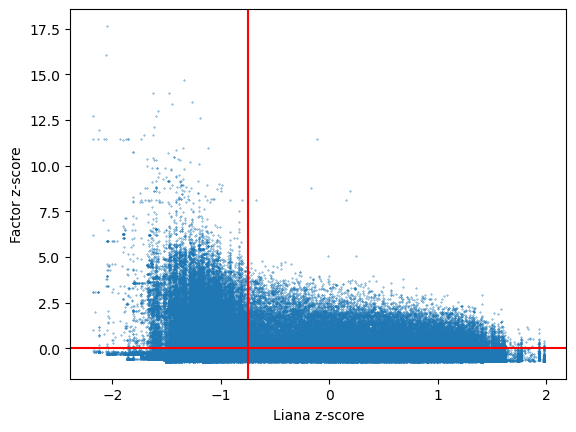

In [9]:
all_liana_send, all_liana_rec, _, _, _ = scfo.make_filtered_lr_signatures(
    liana = all_liana, 
    factor_loadings = all_factors, 
    liana_z_threshold = -0.75, 
    factor_z_threshold = 0, 
    plot_scores = True
)

Put the cell-cell communication loading matrices into scFO-compatible format:

In [10]:
all_liana_send.columns = (
    all_liana_send.columns.astype(str).str.split('|', expand=True)
    .map(lambda x: f"{x[0]} {x[1]}|{x[2]}")
)
all_liana_send

,rec by Astrocyte|Neuron,rec by Endothelial|Neuron,rec by Mg_TAM|Neuron,rec by Mo_TAM|Neuron,rec by Neuron|Neuron,rec by Non_Mac_Myelocyte|Neuron,rec by Non_T_Lymphocyte|Neuron,rec by Oligo|Neuron,rec by Pericyte|Neuron,rec by T cell|Neuron,...,rec by Endothelial|Non_T_Lymphocyte,rec by Mg_TAM|Non_T_Lymphocyte,rec by Mo_TAM|Non_T_Lymphocyte,rec by Neuron|Non_T_Lymphocyte,rec by Non_Mac_Myelocyte|Non_T_Lymphocyte,rec by Non_T_Lymphocyte|Non_T_Lymphocyte,rec by Oligo|Non_T_Lymphocyte,rec by Pericyte|Non_T_Lymphocyte,rec by T cell|Non_T_Lymphocyte,rec by Tumor|Non_T_Lymphocyte
ligand,,,,,,,,,,,,,,,,,,,,,
A2M,1.000000,1.000000,0.000000,0.000000,0.000000,0.493839,1.000000,1.000000,0.235196,0.000000,...,0.784645,0.000000,0.000000,0.000000,0.000000,0.000000,0.750217,0.000000,0.000000,0.000000
ADAM12,2.150831,1.465704,1.352340,1.000000,0.918553,0.441194,1.323402,2.033437,1.683331,1.579330,...,0.000000,0.000000,0.793217,0.000000,0.000000,0.000000,0.572992,0.723462,0.000000,0.855906
ADAM28,1.000000,1.000000,0.770711,0.000000,0.704045,0.938689,0.000000,1.000000,0.786198,0.000000,...,0.714006,0.000000,0.000000,0.000000,0.000000,0.000000,0.734185,0.000000,0.000000,0.247757
ADM,0.383332,0.866618,1.150821,2.040368,1.743440,2.965776,0.439710,1.436929,1.773043,1.408069,...,1.627210,1.383925,3.217733,2.715124,3.078939,1.993312,3.360518,3.824656,1.197763,1.371001
ADM2,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,1.975778,1.000000,0.000000,...,1.000000,0.000000,1.314554,0.916010,1.638241,0.423893,1.439091,0.268603,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFSF9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CD28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
LEFTY1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000


In [11]:
all_liana_rec.columns = (
    all_liana_rec.columns.astype(str).str.split('|', expand=True)
    .map(lambda x: f"{x[0]} {x[1]}|{x[2]}")
)
all_liana_rec

,sent by Neuron|Astrocyte,sent by Oligo|Astrocyte,sent by Pericyte|Astrocyte,sent by Endothelial|Astrocyte,sent by Mg_TAM|Astrocyte,sent by Tumor|Astrocyte,sent by Mo_TAM|Astrocyte,sent by T cell|Astrocyte,sent by Non_Mac_Myelocyte|Astrocyte,sent by Astrocyte|Astrocyte,...,sent by Oligo|Tumor,sent by Pericyte|Tumor,sent by Endothelial|Tumor,sent by Mg_TAM|Tumor,sent by Tumor|Tumor,sent by Mo_TAM|Tumor,sent by T cell|Tumor,sent by Non_Mac_Myelocyte|Tumor,sent by Astrocyte|Tumor,sent by Non_T_Lymphocyte|Tumor
receptor,,,,,,,,,,,,,,,,,,,,,
ABCA1,3.875009,1.641350,0.000000,2.282293,2.824171,0.680492,0.0,3.991009,0.983489,3.279849,...,0.48814,0.887261,0.917861,1.172583,0.279718,1.087522,1.141120,1.227932,1.141832,1.242301
ACTR2,0.797027,0.000000,0.439528,0.000000,0.606898,0.000000,0.0,0.000000,0.524918,0.000000,...,0.00000,0.216700,0.000000,0.287103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ACVR1B,0.413193,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ACVR1B_TGFBR2,0.597021,1.532061,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ACVR1C_TGFBR2,1.000000,1.861518,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GJB2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PILRB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
S1PR5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Build the Ontology object

Once priors are imported and formatted, building the `ontology` object is straightforward using the `make_ontology()` function. This function is flexible to arbitrary user-set annotation modalities:

In [12]:
ontology = scfo.make_ontology(
    factor_loadings=all_factors,
    scored_modalities_ct_aware={
        'regulons': all_regulons,
        'liana_ligand': all_liana_send,
        'liana_receptor': all_liana_rec,
        'slice_treatment': all_treatment,
        'survival_scores': all_survival_scores,
    },
    scored_modalities={
        'nichenet_downstream': all_nichenet,
    },
    gene_set_modalities={
       'hallmark': hallmark_lib_dict,
       'literature': gene_sets_dict,
    },
    n_iter=1000,
)

Permuting for 'nichenet_downstream'...:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating GSEA for 'hallmark'...:   0%|          | 0/275 [00:00<?, ?it/s]

Calculating GSEA for 'literature'...:   0%|          | 0/275 [00:00<?, ?it/s]

Permuting for 'regulons'... [Tumor]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'regulons'... [Mo_TAM]:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Permuting for 'survival_scores'... [T cell]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Neuron]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Oligo]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Pericyte]:   0%|          | 0/1000 [00:00<?, ?it/s]

Permuting for 'survival_scores'... [Endothelial]:   0%|          | 0/1000 [00:00<?, ?it/s]

Visualize the structure of the `ontology` object:

In [13]:
ontology

MuData object with n_obs × n_vars = 275 × 14056
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'gene_names', 'factor_type', 'modality_names'
  9 modalities
    weights:	275 x 6989
    nichenet_downstream:	275 x 6988
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type'
      varm:	'feature_loadings'
      layers:	'pval'
    hallmark:	275 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    literature:	275 x 29
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'gene_sets'
      layers:	'pval'
    regulons:	275 x 368
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_ligand:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_receptor:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    slice_treatment:	275 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'
    survival_scores:	275 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_names', 'feature_loading_row_axis', 'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
      varm:	'feature_loadings'
      layers:	'pval'

# Saving and exporting Ontology objects

This object can be easily saved, shared, and reloaded. It is also useful for visualizing systems-level atlas biology and for projecting onto external data (see separate tutorials). 

The simplest way to save, store, and share an `ontology` object is to keep it as a `MuData`:

In [14]:
ontology.write_h5mu('scFO models/scfo_mofa_gbm.h5mu')

Alternatively, `ontology` objects can be saved/loaded as Excel .xlsx sheets using `export_ontology_excel()` and `load_ontology_excel()`:

In [ ]:
scfo.export_ontology_excel(
    ontology=ontology,
    outdir='scfo_output'
)

Excel workbooks can be large due to extra metadata in the `ontology` object. To save only enrichment scores and loadings:

In [15]:
for mod in ontology.mod.keys():
    
    scfo.modality_scores_to_df(
        ontology=ontology, 
        modality=mod, 
    ).to_csv('scFO models/Enrichment/scfo_mofa_gbm_'+mod+'_enrichment.csv')
    
    if ('feature_loadings' in ontology.mod[mod].varm.keys()):
        scfo.modality_feature_loadings_to_df(
                ontology=ontology,
                modality=mod
            ).to_csv('scFO models/Loadings/scfo_mofa_gbm_'+mod+'_loadings.csv')